# Classificação de Pacientes (Covid-19) utilizando Support Vector Machine (SVM)

Neste projeto, aplicamos o algoritmo clássico de Inteligência Artificial **Support Vector Machine (SVM)** para classificar pacientes como positivos ou negativos para Covid-19. 

As variáveis independentes (*features*) utilizadas são características estatísticas contínuas extraídas das séries temporais de batimentos cardíacos: **Média** e **Variabilidade (Desvio Padrão)**. O SVM foi escolhido por sua robustez matemática em encontrar o hiperplano de margem máxima que separa essas duas classes, sendo altamente eficaz em bases de dados médicas restritas para evitar *overfitting*.


## 0. Instalação de Dependências
Para garantir a reprodutibilidade deste ambiente, a célula abaixo instala todas as bibliotecas necessárias para a execução do pipeline de dados e do modelo de Inteligência Artificial. Se você estiver rodando no Google Colab, a maioria já está instalada, mas é uma boa prática garantir as versões atualizadas.

In [1]:
!pip install numpy pandas scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable


## 1. Importação das Bibliotecas
Abaixo, importamos as dependências necessárias para manipulação de dados (`pandas`, `numpy`), normalização matemática e o modelo SVM da biblioteca `scikit-learn`, além das métricas de avaliação e ferramentas de plotagem gráfica.

In [9]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bibliotecas de Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Configuração visual dos gráficos
plt.style.use('ggplot')

## 2. Extração de Características (Feature Extraction) e Estruturação dos Dados
Nesta etapa, o algoritmo percorre os arquivos `.json` (onde estão os rótulos de alerta/classe alvo) e os arquivos `.csv` (onde estão as séries temporais).
Reduzimos as milhares de linhas de batimentos cardíacos a apenas duas dimensões estatísticas por paciente:
1. **Media_HR**: O valor médio da frequência cardíaca.
2. **Variabilidade_HR**: O desvio padrão, representando o quão instável está o batimento.

A variável alvo (`Situacao_Alarmante`) será `1` se houver um alerta de nível "2" no JSON, ou `0` caso contrário.

In [10]:
dados_consolidados = []
caminho_diretorio = './dados'
arquivos_json = glob.glob(os.path.join(caminho_diretorio, '*.json'))

# Parâmetro da métrica: Quantas noites SEGUIDAS de alerta crítico definem um caso positivo?
NOITES_CONSECUTIVAS_NECESSARIAS = 5

for caminho_json in arquivos_json:
    identificador = os.path.basename(caminho_json).split('.')[0]
    caminho_csv = os.path.join(caminho_diretorio, f"{identificador}.csv")
    
    if os.path.exists(caminho_csv):
        with open(caminho_json, 'r') as f:
            dados_json = json.load(f)
            alertas = [item['val'] for item in dados_json.get('nightsignal', [])]
            
            consecutivos = 0
            max_consecutivos = 0
            for val in alertas:
                if val == '2':
                    consecutivos += 1
                    if consecutivos > max_consecutivos:
                        max_consecutivos = consecutivos
                else:
                    consecutivos = 0
            
            situacao_alarmante = 1 if max_consecutivos >= NOITES_CONSECUTIVAS_NECESSARIAS else 0
            
        df_csv = pd.read_csv(caminho_csv)
        media_hr = df_csv['HR_Value'].mean()
        std_hr = df_csv['HR_Value'].std() 
        
        dados_consolidados.append({
            'Identificador': identificador,
            'Media_HR': media_hr,
            'Variabilidade_HR': std_hr,
            'Target': situacao_alarmante 
        })

df_projeto = pd.DataFrame(dados_consolidados)
print(f"Base de dados criada. Total de instâncias (pacientes): {len(df_projeto)}")
display(df_projeto)

Base de dados criada. Total de instâncias (pacientes): 20


,Identificador,Media_HR,Variabilidade_HR,Target
0,P1,87.233447,20.168591,1
1,P10,58.600994,9.695273,0
2,P11,84.116685,12.310301,0
3,P12,93.154431,12.331111,1
4,P13,77.218892,18.309986,1
5,P14,80.771234,10.075717,1
6,P15,81.231045,12.529141,1
7,P16,95.584673,13.234067,0
8,P17,84.209580,11.885733,0
9,P18,78.852927,13.888713,1


## 3. Separação (Holdout) e Padronização dos Dados (Z-Score)
Modelos de margem geométrica como o SVM são extremamente sensíveis à escala dos dados. Se a média oscila na casa dos 80 e o desvio padrão na casa dos 5, o algoritmo dará um peso matematicamente incorreto à média. 

Utilizamos o `StandardScaler` para centralizar as *features* na média zero e variância unitária. Além disso, dividimos a base em **80% para Treino** e **20% para Teste**.

In [11]:
# Definindo as Features (X) e o Target (y)
X = df_projeto[['Media_HR', 'Variabilidade_HR']]
y = df_projeto['Target']

# Separação Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Instanciando e aplicando o padronizador matemático
scaler = StandardScaler()

# O 'fit' aprende a média e variância apenas dos dados de treino, e o 'transform' aplica a escala
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Treinamento do Modelo SVM e Inferência
Aqui instanciamos o `SVC` (Support Vector Classifier). 
Neste caso, utilizaremos um **Kernel Linear**. Isso significa que o algoritmo tentará traçar uma linha reta (um hiperplano linear) no espaço 2D bidimensional formado pela nossa Média e Variabilidade.
O parâmetro `C` controla a penalidade por classificações erradas na margem.

In [12]:
# Instanciação do modelo Clássico
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

# FASE DE TREINAMENTO (Aprendizado de Máquina)
# O modelo encontra o hiperplano e os vetores de suporte matemáticos
svm_model.fit(X_train_scaled, y_train)

# FASE DE INFERÊNCIA (Teste)
# Aplicamos o modelo treinado nos dados não vistos
y_pred = svm_model.predict(X_test_scaled)

## 5. Avaliação de Desempenho
Abaixo extraímos as métricas clássicas de Inteligência Artificial:
* **Acurácia**: Taxa de acerto global.
* **Precisão e Recall (Sensibilidade)**: Essenciais no escopo médico, pois nos dizem o quanto o modelo acerta quando prediz um caso positivo de Covid-19 e se ele está deixando escapar falsos negativos.
* **Matriz de Confusão**: Visualização exata dos Falsos Positivos e Falsos Negativos.

RELATÓRIO DE CLASSIFICAÇÃO - SVM
              precision    recall  f1-score   support

Negativo (0)       1.00      0.50      0.67         2
Positivo (1)       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4

Acurácia Global: 75.00%



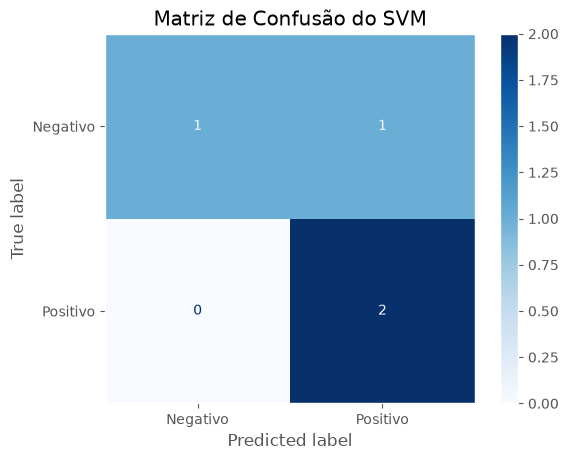

In [13]:
# Relatório Estatístico de Classificação
print("="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO - SVM")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.2%}\n")

# Plotagem da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão do SVM")
plt.grid(False)
plt.show()

## 6. Visualização do Hiperplano e Vetores de Suporte
Como utilizamos apenas duas *features*, podemos plotar graficamente o espaço de decisão do SVM. 
A linha central é o hiperplano ótimo. As linhas tracejadas delimitam a "margem de segurança" criada pelo algoritmo. Os pontos que tocam as linhas tracejadas são os **Vetores de Suporte** (os dados cruciais que definem o modelo).

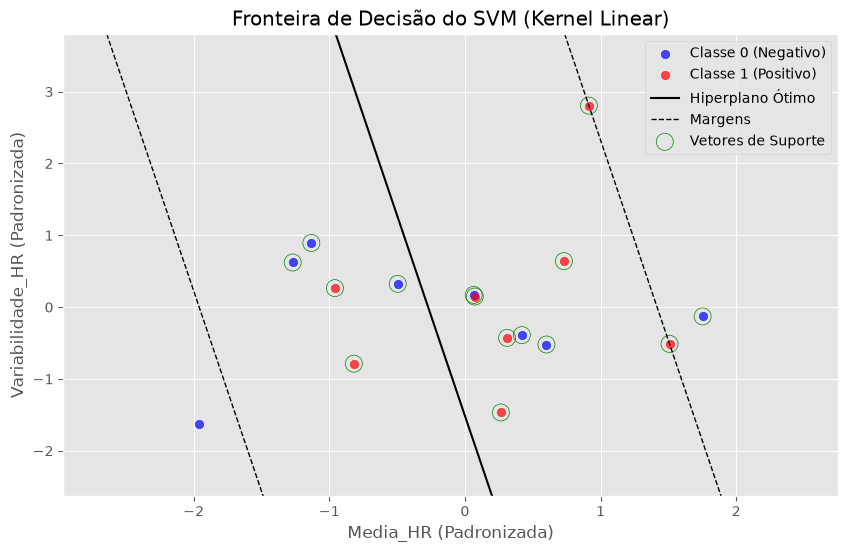

In [14]:
# Criação de um grid para visualização do espaço de decisão
plt.figure(figsize=(10, 6))

# Plotando os pontos de dados reais (Treino)
plt.scatter(X_train_scaled[y_train==0, 0], X_train_scaled[y_train==0, 1], color='blue', label='Classe 0 (Negativo)', alpha=0.7)
plt.scatter(X_train_scaled[y_train==1, 0], X_train_scaled[y_train==1, 1], color='red', label='Classe 1 (Positivo)', alpha=0.7)

# Extraindo os parâmetros da equação do plano do modelo SVM
w = svm_model.coef_[0]
b = svm_model.intercept_[0]
x_points = np.linspace(X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1, 100)

# Calculando a reta do hiperplano (w0*x0 + w1*x1 + b = 0)
y_points = -(w[0] / w[1]) * x_points - b / w[1]
plt.plot(x_points, y_points, 'k-', label='Hiperplano Ótimo')

# Calculando e plotando as margens
margin = 1 / np.linalg.norm(w)
y_margin_up = y_points + np.sqrt(1 + (w[0]/w[1])**2) * margin
y_margin_down = y_points - np.sqrt(1 + (w[0]/w[1])**2) * margin

plt.plot(x_points, y_margin_up, 'k--', linewidth=1, label='Margens')
plt.plot(x_points, y_margin_down, 'k--', linewidth=1)

# Destacando os Vetores de Suporte (Support Vectors)
support_vectors = svm_model.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='green', label='Vetores de Suporte')

plt.title('Fronteira de Decisão do SVM (Kernel Linear)')
plt.xlabel('Media_HR (Padronizada)')
plt.ylabel('Variabilidade_HR (Padronizada)')
plt.legend()
plt.ylim(X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1)
plt.xlim(X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1)
plt.show()

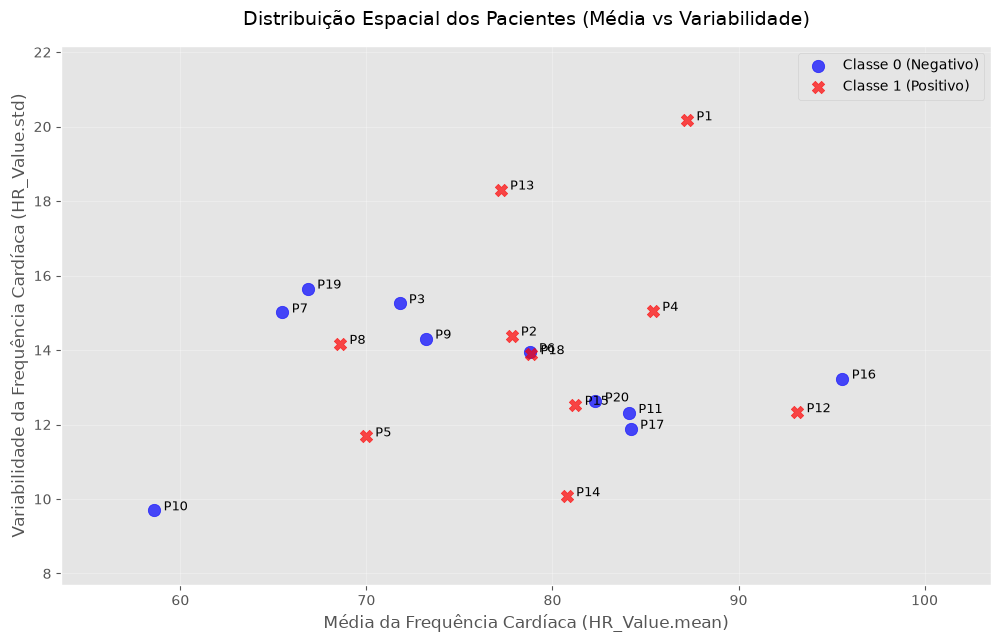

In [16]:
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuração do Gráfico
# ==========================================
plt.figure(figsize=(12, 7))

# Extraindo os valores diretamente do dataframe para facilitar a plotagem
X_bruto = df_projeto[['Media_HR', 'Variabilidade_HR']].values
y_bruto = df_projeto['Target'].values

# Plotando os dados reais (apenas os pontos)
plt.scatter(X_bruto[y_bruto==0, 0], X_bruto[y_bruto==0, 1], color='blue', label='Classe 0 (Negativo)', alpha=0.7, s=80)
plt.scatter(X_bruto[y_bruto==1, 0], X_bruto[y_bruto==1, 1], color='red', label='Classe 1 (Positivo)', alpha=0.7, s=80, marker='X')

# ==========================================
# 2. Adicionando os Identificadores
# ==========================================
# Colocando o texto (P1, P2...) ao lado de cada paciente
for i in range(df_projeto.shape[0]):
    plt.text(
        x=df_projeto['Media_HR'].iloc[i] + 0.5,  # +0.5 para o texto não ficar em cima do ponto
        y=df_projeto['Variabilidade_HR'].iloc[i], 
        s=df_projeto['Identificador'].iloc[i], 
        fontsize=9,
        color='black'
    )

# ==========================================
# 3. Formatação Visual
# ==========================================
plt.title('Distribuição Espacial dos Pacientes (Média vs Variabilidade)', fontsize=14, pad=15)
plt.xlabel('Média da Frequência Cardíaca (HR_Value.mean)', fontsize=12)
plt.ylabel('Variabilidade da Frequência Cardíaca (HR_Value.std)', fontsize=12)
plt.legend(loc='best')

# Ajustando as "bordas" do gráfico para os dados não ficarem colados nas margens
plt.ylim(X_bruto[:, 1].min() - 2, X_bruto[:, 1].max() + 2)
plt.xlim(X_bruto[:, 0].min() - 5, X_bruto[:, 0].max() + 8)

# Mantém uma grelha suave para ajudar na leitura dos valores
plt.grid(True, alpha=0.3)
plt.show()